## Putting it all together in pipelines

Notebook 8 closed by pointing here. Across eight notebooks we have built up a toolkit: imputing what is missing, scaling what is skewed, encoding what is categorical, constructing what is not in the file yet, and selecting what earns its place. Every one of those steps had the same warning attached to it, and we wrote it out in full in notebook 3:

> Any object with a `fit` method learns something from data, and everything it learns must come from the training set.

So far we have followed that rule by remembering it. This notebook stops relying on memory. `Pipeline` and `ColumnTransformer` turn the rule into a property of the object, so that the wrong thing becomes awkward to write rather than easy to write by accident.

That is the honest reason to use them. The dishonest reason, which you will read often, is that leaving preprocessing outside a pipeline will wreck your scores. Section 2 measures exactly how much each kind of leak is worth, and the answer ranges from nothing at all to catastrophic depending on which transformer you are talking about. The point of a pipeline is that you do not have to know in advance which case you are in.

**What this notebook covers:**

1. A pipeline as a single object with a single `fit`
2. The leakage a pipeline prevents, with each kind measured
3. `ColumnTransformer`, and how to see what came out of it
4. Custom transformers, stateless and stateful
5. Feature selection as a pipeline step
6. Searching over preprocessing choices, not just model hyperparameters
7. What you are allowed to claim at the end
8. Saving a pipeline and the things that break in production

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib, os, sklearn

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (StandardScaler, MinMaxScaler, RobustScaler,
                                   OneHotEncoder, OrdinalEncoder, TargetEncoder,
                                   FunctionTransformer)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import (cross_val_score, StratifiedKFold, GridSearchCV,
                                     train_test_split)
from sklearn.metrics import roc_auc_score

SEED = 42
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

def new_lr():
    return LogisticRegression(max_iter=2000, random_state=SEED)

print('sklearn', sklearn.__version__)

sklearn 1.8.0


In [2]:
telco = pd.read_csv('datasets/telco_churn.csv')
telco['TotalCharges'] = pd.to_numeric(telco['TotalCharges'], errors='coerce')

print('missing values before the tenure filter:', int(telco.isna().sum().sum()))
telco = telco[telco['tenure'] > 0].reset_index(drop=True)
print('missing values after the tenure filter: ', int(telco.isna().sum().sum()))

SERVICES = ['PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
            'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
            'StreamingMovies']

# nb4 built this: the nine service columns pasted into one high-cardinality label
telco['bundle'] = telco[SERVICES].apply(lambda row: '|'.join(row.astype(str)), axis=1)

y = (telco['Churn'] == 'Yes').astype(int)
X = telco.drop(columns=['Churn'])

print()
print('rows', len(X), ' churn rate %.4f' % y.mean())
print('bundle categories:', X['bundle'].nunique())

missing values before the tenure filter: 11
missing values after the tenure filter:  0

rows 7032  churn rate 0.2658
bundle categories: 322


Same 7,032 rows and 26.6% churn rate the series has used since notebook 1, so every number below is comparable with the ones we already have.

Two things to notice in that output, because both come back later.

The eleven missing values live entirely in rows with `tenure == 0`, so filtering those rows leaves a dataset with **no missing values at all**. We are still going to put an imputer in the pipeline. Section 8 shows why: the training data having no gaps says nothing about the rows you will be asked to score next week.

`bundle` is notebook 4's construction, the nine service columns joined into one label. It has 322 categories. `customerID` is higher still at 7,032, but that one is an identifier we are going to throw away, so `bundle` is the high-cardinality column we actually have to make a decision about.

### 1. A pipeline is one object with one fit

A `Pipeline` is a list of `(name, step)` pairs. Every step except the last must implement `fit` and `transform`. The last one only needs `fit`, so it is usually the model.

When you call `fit`, sklearn walks the list, calling `fit_transform` on each step and handing the output to the next. When you call `predict`, it walks the same list calling `transform`, and never calls `fit` again. That second sentence is the whole safety property: **there is no code path in which `predict` refits anything.**

In [3]:
NUMERIC = ['tenure', 'MonthlyCharges', 'TotalCharges']

simple = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale',  StandardScaler()),
    ('model',  new_lr()),
])

simple.fit(X[NUMERIC], y)

print('steps:', list(simple.named_steps))
print()
print('what each fitted step learned, all of it from the rows passed to fit:')
print('  imputer medians:', simple.named_steps['impute'].statistics_.round(2))
print('  scaler means:   ', simple.named_steps['scale'].mean_.round(2))
print('  model coefs:    ', simple.named_steps['model'].coef_.round(3))
print()
print('5-fold AUC %.4f  (notebook 1 baseline: 0.8087)'
      % cross_val_score(simple, X[NUMERIC], y, cv=CV, scoring='roc_auc', n_jobs=1).mean())

steps: ['impute', 'scale', 'model']

what each fitted step learned, all of it from the rows passed to fit:
  imputer medians: [  29.     70.35 1397.48]
  scaler means:    [  32.42   64.8  2283.3 ]
  model coefs:     [[-1.616  0.913  0.299]]



5-fold AUC 0.8087  (notebook 1 baseline: 0.8087)


0.8087, matching the number notebook 1 established and every notebook since has measured against. The pipeline changed nothing about the model. It changed where the medians and the means are allowed to come from.

The fitted pieces are still reachable through `named_steps`, which matters more than it sounds. A pipeline is not a black box you give up inspecting; it is the same objects with the plumbing done for you.

### 2. How much is each kind of leak actually worth

The leakage rule has now appeared six times in this series, once for each family of transformer:

| Notebook | Transformer | What it learns |
|---|---|---|
| 2 | imputer | a median or a mean |
| 3 | scaler | a mean and a standard deviation |
| 4 | encoder | a category list, or a per-category target mean |
| 6 | vectoriser | a vocabulary |
| 7 | group aggregate | a per-group statistic |
| 8 | selector | which columns survive |

Every one of those is a `fit`, and every one of them can be run on the whole dataset before splitting. The usual advice stops at "so do not do that". We are going to measure it instead, because the sizes are wildly different and the difference is the interesting part.

The recipe for each row is the same. The leaky version fits the transformer on all the data, then cross-validates the model on the transformed result. The honest version puts the transformer inside a pipeline, so each fold refits it on that fold's training portion. Same folds, same model, same seed.

In [4]:
leaks = {}

# --- scaler, on Telco ---
leaky_X = StandardScaler().fit_transform(X[NUMERIC])          # fitted on all 7,032 rows
a = cross_val_score(new_lr(), leaky_X, y, cv=CV, scoring='roc_auc', n_jobs=1).mean()
b = cross_val_score(Pipeline([('scale', StandardScaler()), ('model', new_lr())]),
                    X[NUMERIC], y, cv=CV, scoring='roc_auc', n_jobs=1).mean()
leaks['scaler (Telco)'] = (a, b)
print('scaler   leaky %.6f   honest %.6f   difference %+.6f' % (a, b, a - b))
first_fold = next(iter(CV.split(X, y)))[0]
all_rows = StandardScaler().fit(X[NUMERIC]).mean_
one_fold = StandardScaler().fit(X[NUMERIC].iloc[first_fold]).mean_
print('  column means, all 7,032 rows vs the %d rows of one training fold:' % len(first_fold))
print('   ', all_rows.round(3))
print('   ', one_fold.round(3))
print('  they differ by %s, at most %.2f%%'
      % (np.round(np.abs(one_fold - all_rows), 3), (np.abs(one_fold - all_rows) / all_rows).max() * 100))

scaler   leaky 0.808677   honest 0.808676   difference +0.000001
  column means, all 7,032 rows vs the 5625 rows of one training fold:
    [  32.422   64.798 2283.3  ]
    [  32.522   64.878 2297.903]
  they differ by [ 0.1    0.079 14.602], at most 0.64%


One part in a million, which is float arithmetic rather than a finding. The reason is visible underneath: a mean over all 7,032 rows and a mean over the rows of a single training fold agree to well under one percent on every column, because a mean is a stable statistic and dropping a fifth of the rows at random barely shifts it.

This is the honest starting point. **The leak that gets used to scare people in tutorials is worth nothing here.**

In [5]:
# --- imputer, on Titanic, because Telco has nothing left to impute ---
titanic = pd.read_csv('datasets/titanic.csv')
X_tt = titanic[['Age', 'Fare', 'Pclass', 'SibSp', 'Parch']]
y_tt = titanic['Survived']
print('Titanic Age missing: %d of %d rows' % (X_tt['Age'].isna().sum(), len(X_tt)))

leaky_X = SimpleImputer(strategy='median').fit_transform(X_tt)   # median over all 891 rows
a = cross_val_score(Pipeline([('scale', StandardScaler()), ('model', new_lr())]),
                    leaky_X, y_tt, cv=CV, scoring='roc_auc', n_jobs=1).mean()
b = cross_val_score(Pipeline([('impute', SimpleImputer(strategy='median')),
                              ('scale', StandardScaler()), ('model', new_lr())]),
                    X_tt, y_tt, cv=CV, scoring='roc_auc', n_jobs=1).mean()
leaks['imputer (Titanic)'] = (a, b)
print('imputer  leaky %.6f   honest %.6f   difference %+.6f' % (a, b, a - b))
print('  Age median over everything: %.2f' % X_tt['Age'].median())
print('  Age median per training fold:', [X_tt.iloc[tr]['Age'].median() for tr, _ in CV.split(X_tt, y_tt)])

Titanic Age missing: 177 of 891 rows
imputer  leaky 0.725968   honest 0.725834   difference +0.000134
  Age median over everything: 28.00
  Age median per training fold: [np.float64(28.0), np.float64(29.0), np.float64(28.0), np.float64(28.0), np.float64(28.0)]


A little bigger, and still nothing you could act on. The per-fold medians are 28, 29, 28, 28, 28 against 28.00 for the whole file, so four of the five folds impute the identical value a leaky version would have used.

Notice what makes these two cases small. Both transformers learn **a couple of aggregate statistics per column**, a median for the imputer and a mean and standard deviation for the scaler, each computed from every available row. Dropping 20% of the rows barely moves any of them. Now we change to a transformer that learns one number per category.

In [6]:
# --- target encoding, on the 322-category bundle ---
category_means = y.groupby(X['bundle']).mean()          # computed from every row, labels included
leaky_frame = X[NUMERIC].assign(bundle_encoded=X['bundle'].map(category_means))
a = cross_val_score(Pipeline([('scale', StandardScaler()), ('model', new_lr())]),
                    leaky_frame, y, cv=CV, scoring='roc_auc', n_jobs=1).mean()

honest = Pipeline([
    ('prep', ColumnTransformer([('num', StandardScaler(), NUMERIC),
                                ('cat', TargetEncoder(random_state=SEED), ['bundle'])])),
    ('model', new_lr()),
])
b = cross_val_score(honest, X[NUMERIC + ['bundle']], y, cv=CV, scoring='roc_auc', n_jobs=1).mean()
leaks['target encoder (bundle)'] = (a, b)
print('encoder  leaky %.6f   honest %.6f   difference %+.6f' % (a, b, a - b))

sizes = X['bundle'].value_counts()
print()
print('  bundle categories: %d, median size %d rows, %d of them have 5 rows or fewer'
      % (len(sizes), int(sizes.median()), int((sizes <= 5).sum())))

encoder  leaky 0.845031   honest 0.824909   difference +0.020121

  bundle categories: 322, median size 9 rows, 84 of them have 5 rows or fewer


Two points of AUC. Notebook 4 measured this same encoder on this same column and reported 0.8450 leaked against 0.8250 honest, so the leaked figure reproduces exactly and the honest one lands a ten-thousandth away.

The reason is in the category sizes. When a category holds a handful of rows, the mean of the target over those rows is mostly made of **this row's own label**. The encoder is not learning a property of the category, it is handing the model a smoothed copy of the answer. Notebook 7 measured how that scales: the leak shrinks as `1 / group_size`, which is why a 322-category column leaks and a 3-category column does not.

`TargetEncoder` avoids this by cross-fitting internally, so the value a training row receives is computed from other rows. That is not something you get for free by putting it in a pipeline, it is something the class does deliberately, and it is worth knowing the difference.

In [7]:
# --- selection, twice: once where it is harmless, once where it is not ---
rng = np.random.default_rng(0)
noise_X = pd.DataFrame(rng.normal(size=(200, 2000)))
coin_y = pd.Series(rng.integers(0, 2, 200))

chosen = SelectKBest(f_classif, k=20).fit(noise_X, coin_y).get_support()
a = cross_val_score(new_lr(), noise_X.loc[:, chosen], coin_y, cv=CV, scoring='accuracy', n_jobs=1).mean()
b = cross_val_score(Pipeline([('select', SelectKBest(f_classif, k=20)), ('model', new_lr())]),
                    noise_X, coin_y, cv=CV, scoring='accuracy', n_jobs=1).mean()
leaks['selector (2000 noise columns)'] = (a, b)
print('selector on pure noise, accuracy: leaky %.4f  honest %.4f  difference %+.4f' % (a, b, a - b))

real = X[NUMERIC].assign(log_tenure=np.log1p(X['tenure']),
                         tenure_squared=X['tenure'] ** 2,
                         num_services=X[SERVICES].isin(['Yes', 'DSL', 'Fiber optic']).sum(axis=1))
chosen = SelectKBest(f_classif, k=3).fit(real, y).get_support()
a = cross_val_score(Pipeline([('scale', StandardScaler()), ('model', new_lr())]),
                    real.loc[:, chosen], y, cv=CV, scoring='roc_auc', n_jobs=1).mean()
b = cross_val_score(Pipeline([('select', SelectKBest(f_classif, k=3)),
                              ('scale', StandardScaler()), ('model', new_lr())]),
                    real, y, cv=CV, scoring='roc_auc', n_jobs=1).mean()
leaks['selector (real Telco columns)'] = (a, b)
print('selector on real columns,  AUC:   leaky %.4f  honest %.4f  difference %+.4f' % (a, b, a - b))

# why the two answers differ: do the folds agree on what to select?
noise_picks = [set(np.flatnonzero(SelectKBest(f_classif, k=20)
                                  .fit(noise_X.iloc[tr], coin_y.iloc[tr]).get_support()))
               for tr, _ in CV.split(noise_X, coin_y)]
real_picks = [tuple(real.columns[SelectKBest(f_classif, k=3)
                                 .fit(real.iloc[tr], y.iloc[tr]).get_support()])
              for tr, _ in CV.split(real, y)]
print()
print('noise: %d columns chosen by all 5 folds, %d chosen by at least one'
      % (len(set.intersection(*noise_picks)), len(set().union(*noise_picks))))
print('real:  %d distinct selections across the 5 folds, %s'
      % (len(set(real_picks)), list(real_picks[0])))

selector on pure noise, accuracy: leaky 0.7450  honest 0.4750  difference +0.2700


selector on real columns,  AUC:   leaky 0.7412  honest 0.7412  difference +0.0000



noise: 1 columns chosen by all 5 folds, 68 chosen by at least one
real:  1 distinct selections across the 5 folds, ['tenure', 'log_tenure', 'tenure_squared']


The same transformer, the same mistake, two answers that could not be further apart. On 2,000 noise columns and a coin-flip target, selecting first reports 74.5% accuracy for a problem whose true answer is 50%. On six real columns it is worth **exactly zero**.

The last two lines say why, and this is the most useful idea in the section: the size of a selection leak equals the **instability** of the selection. On the real columns all five folds choose the identical three, so choosing them in advance changes nothing at all. On the noise columns one column survives every fold and 68 are picked by at least one, and every one of those disagreements is the selector fitting itself to rows it is about to be scored on. Notebook 8 reached the same conclusion from the other end, and got the same two counts.

                  transformer    leaky   honest  difference
selector (real Telco columns) 0.741214 0.741214    0.000000
               scaler (Telco) 0.808677 0.808676    0.000001
            imputer (Titanic) 0.725968 0.725834    0.000134
      target encoder (bundle) 0.845031 0.824909    0.020121
selector (2000 noise columns) 0.745000 0.475000    0.270000


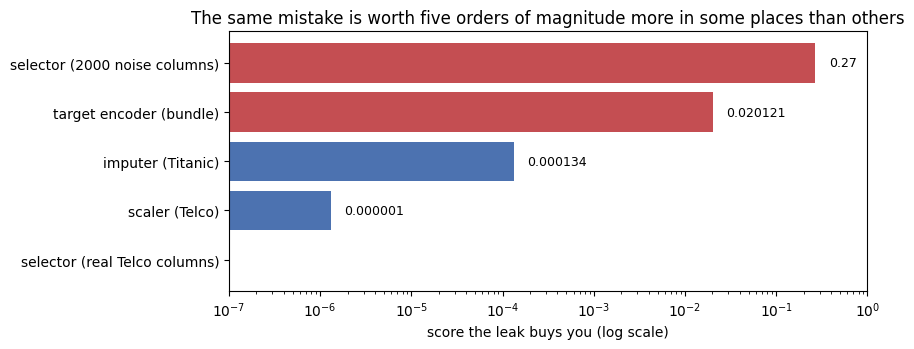

In [8]:
summary = (pd.DataFrame([(k, v[0], v[1], v[0] - v[1]) for k, v in leaks.items()],
                        columns=['transformer', 'leaky', 'honest', 'difference'])
             .sort_values('difference'))
print(summary.to_string(index=False, float_format=lambda v: '%.6f' % v))

fig, ax = plt.subplots(figsize=(9, 3.6))
labels = summary['transformer'].tolist()
vals = summary['difference'].clip(lower=1e-7).tolist()
colors = ['#4c72b0' if d < 0.01 else '#c44e52' for d in summary['difference']]
ax.barh(labels, vals, color=colors)
ax.set_xscale('log')
ax.set_xlim(1e-7, 1)
ax.set_xlabel('score the leak buys you (log scale)')
ax.set_title('The same mistake is worth five orders of magnitude more in some places than others')
for i, d in enumerate(summary['difference']):
    ax.text(max(d, 1e-7) * 1.4, i, ('0' if d <= 0 else '%.6f' % d).rstrip('0').rstrip('.'),
            va='center', fontsize=9)
plt.tight_layout()
plt.show()

That spread is the argument, and it is not the argument you usually get handed.

If leaking a scaler cost two points of AUC, everyone would be careful with scalers and nobody would need a pipeline. It costs a millionth of a point, so being careful with scalers feels like superstition, and people generalise from that to being careless with encoders and selectors, where it costs real money.

The pipeline is worth using because **you cannot tell which row of that table you are standing in until after you have done the work properly**. It costs nothing to be right about all six at once.

There is a sharper version of this that notebook 6 arrived at from the text side: you cannot measure how much a leak is worth from inside a leaky experiment, because the number you would use to decide is the compromised one. The table above only exists because we computed the honest column too.

### 3. ColumnTransformer, and seeing what came out of it

A single `Pipeline` applies every step to every column, which is fine when the columns are all numeric and useless otherwise. You cannot scale `PaymentMethod` and you cannot one-hot encode `MonthlyCharges`.

`ColumnTransformer` takes a list of `(name, transformer, columns)` triples, runs each on its own slice, and pastes the results together side by side. Each triple can itself be a `Pipeline`, which is how a column group gets more than one step.

Telco splits into five groups, and each one is a decision an earlier notebook made:

In [9]:
NOMINAL   = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
             'PaperlessBilling', 'PaymentMethod', 'InternetService']
ORDINAL   = ['Contract']
CONTRACT_ORDER = [['Month-to-month', 'One year', 'Two year']]

for name, cols in [('numeric', NUMERIC), ('nominal', NOMINAL), ('ordinal', ORDINAL),
                   ('high cardinality', ['bundle']), ('constructed from', SERVICES)]:
    print('%-18s %d columns  %s' % (name, len(cols), cols if len(cols) < 8 else cols[:3] + ['...']))
print()
print('dropped entirely:  customerID (notebook 1: a perfect identifier, 7,032 distinct values)')

numeric            3 columns  ['tenure', 'MonthlyCharges', 'TotalCharges']
nominal            7 columns  ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PaperlessBilling', 'PaymentMethod', 'InternetService']
ordinal            1 columns  ['Contract']
high cardinality   1 columns  ['bundle']
constructed from   9 columns  ['PhoneService', 'MultipleLines', 'InternetService', '...']

dropped entirely:  customerID (notebook 1: a perfect identifier, 7,032 distinct values)


In [10]:
def count_services(frame):
    """nb7's num_services: how many of the nine services this customer actually has."""
    return frame.isin(['Yes', 'DSL', 'Fiber optic']).sum(axis=1).to_frame('num_services')

def service_feature_names(transformer, input_features):
    return ['num_services']

service_counter = FunctionTransformer(count_services, feature_names_out=service_feature_names)

def make_preprocessor():
    return ColumnTransformer(
        transformers=[
            ('num', Pipeline([('impute', SimpleImputer(strategy='median')),
                              ('scale', StandardScaler())]), NUMERIC),
            ('svc', Pipeline([('count', service_counter),
                              ('scale', StandardScaler())]), SERVICES),
            ('ord', OrdinalEncoder(categories=CONTRACT_ORDER), ORDINAL),
            ('nom', OneHotEncoder(handle_unknown='ignore', drop='if_binary',
                                  sparse_output=False), NOMINAL),
            ('hi',  TargetEncoder(random_state=SEED), ['bundle']),
        ],
        remainder='drop',
        verbose_feature_names_out=False,
    )

def make_full_pipe():
    return Pipeline([('prep', make_preprocessor()), ('model', new_lr())])

make_full_pipe()

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('svc', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers conta

That last line prints the pipeline rather than a score. In a notebook sklearn renders it as a clickable diagram, which is the fastest way to check that a nested structure is the one you meant to build. Click any box to see its parameters.

Now the score, against the chain the series has been building since notebook 1.

In [11]:
scores = {
    'numeric only (nb1)': X[NUMERIC],
    '+ log_tenure, tenure_squared (nb1)': X[NUMERIC].assign(
        log_tenure=np.log1p(X['tenure']), tenure_squared=X['tenure'] ** 2),
    '+ num_services (nb7)': X[NUMERIC].assign(
        log_tenure=np.log1p(X['tenure']), tenure_squared=X['tenure'] ** 2,
        num_services=X[SERVICES].isin(['Yes', 'DSL', 'Fiber optic']).sum(axis=1)),
}
for label, frame in scores.items():
    print('%-38s %.4f' % (label, cross_val_score(
        Pipeline([('scale', StandardScaler()), ('model', new_lr())]),
        frame, y, cv=CV, scoring='roc_auc', n_jobs=1).mean()))

full_cv = cross_val_score(make_full_pipe(), X, y, cv=CV, scoring='roc_auc', n_jobs=1).mean()
print('%-38s %.4f' % ('everything, one ColumnTransformer', full_cv))

numeric only (nb1)                     0.8087
+ log_tenure, tenure_squared (nb1)     0.8159
+ num_services (nb7)                   0.8241


everything, one ColumnTransformer      0.8416


0.8087, 0.8159, 0.8241 reproduce the series exactly, and the assembled pipeline reaches 0.8416.

That is a real gain of +0.0329 over the numeric baseline, and it comes from columns the earlier notebooks worked out how to handle rather than from any cleverness here. `Contract` in the right order was notebook 4. `num_services` was notebook 7. The one-hot settings were notebook 4. Section 7 checks this number against rows that had no part in producing it, because a 5-fold mean is not yet something you are allowed to quote.

In [12]:
prep = make_preprocessor().set_output(transform='pandas')
transformed = prep.fit_transform(X, y)

print('%d raw columns in, %d features out' % (X.shape[1], transformed.shape[1]))
print()
print(transformed.head(3).round(3).to_string())

21 raw columns in, 18 features out

   tenure  MonthlyCharges  TotalCharges  num_services  Contract  gender_Male  SeniorCitizen_1  Partner_Yes  Dependents_Yes  PaperlessBilling_Yes  PaymentMethod_Bank transfer (automatic)  PaymentMethod_Credit card (automatic)  PaymentMethod_Electronic check  PaymentMethod_Mailed check  InternetService_DSL  InternetService_Fiber optic  InternetService_No  bundle
0  -1.280          -1.162        -0.994        -0.929       0.0          0.0              0.0          1.0             0.0                   1.0                                      0.0                                    0.0                             1.0                         0.0                  1.0                          0.0                 0.0   0.385
1   0.064          -0.261        -0.174        -0.064       1.0          1.0              0.0          0.0             0.0                   0.0                                      0.0                                    0.0              

`set_output(transform='pandas')` is the single most useful line in this notebook for debugging. Without it a `ColumnTransformer` hands you an unlabelled numpy array and you are counting columns on your fingers to work out which one blew up. With it you get a DataFrame whose column names come from `get_feature_names_out`.

Two details that save time:

- `verbose_feature_names_out=False` is what keeps the names as `tenure` rather than `num__tenure`. The verbose form is the default because it guarantees uniqueness, so turn it off only when you know your groups do not collide.
- `drop='if_binary'` is why `gender` produced one column and not two. For a two-category column the second dummy is the first one flipped, so it carries no information and gives a linear model a redundant coefficient to fit.

One trap worth meeting on purpose, since the error message is not obvious:

In [13]:
sparse_prep = ColumnTransformer(
    [('nom', OneHotEncoder(handle_unknown='ignore'), NOMINAL)],   # sparse_output defaults to True
    remainder='drop').set_output(transform='pandas')
try:
    sparse_prep.fit_transform(X)
except Exception as err:
    print('%s: %s' % (type(err).__name__, err))

ValueError: Pandas output does not support sparse data. Set sparse_output=False to output pandas dataframes or disable Pandas output via` ohe.set_output(transform="default").


`OneHotEncoder` returns a sparse matrix by default and a DataFrame cannot hold one, so pandas output and default one-hot settings are incompatible. On a 322-category column sparse is the right choice and you should keep it, giving up the DataFrame view. On seven low-cardinality columns it makes no difference and `sparse_output=False` is worth it.

The other setting worth being deliberate about is `remainder`. It defaults to `'drop'`, which means any column you did not list is discarded. That sounds like a footgun and is actually the safest default available:

In [14]:
passthrough = ColumnTransformer([('num', StandardScaler(), NUMERIC)],
                                remainder='passthrough', verbose_feature_names_out=False)
try:
    Pipeline([('prep', passthrough), ('model', new_lr())]).fit(X, y)
except Exception as err:
    print('remainder="passthrough": %s: %s' % (type(err).__name__, str(err).split(chr(10))[0]))
print()
print('remainder="drop" instead: customerID never reaches the model, and we said so on purpose.')

remainder="passthrough": ValueError: could not convert string to float: '7590-VHVEG'

remainder="drop" instead: customerID never reaches the model, and we said so on purpose.


With `passthrough`, `customerID` goes straight to the model and logistic regression cannot parse `7590-VHVEG`. Here that is a loud, immediate failure, which is the good case. Notebook 1 showed the bad case: give the same column to a decision tree and it fits it happily, scoring 100% on training rows and 61.3% on test, below the 73.5% you get by predicting the majority class.

Listing your columns explicitly is a few lines of typing that buys you a schema. A column that appears in the source file next month does not silently join your model.

### 4. Custom transformers, stateless and stateful

Sooner or later the transformation you want is not in sklearn. The interface you need to satisfy is small: a `fit` that returns `self`, and a `transform` that returns the transformed data. `BaseEstimator` and `TransformerMixin` supply `get_params`, `set_params` and `fit_transform` on top of that.

Before writing a class, ask whether your transformation **learns anything**. This is the distinction that decides everything else.

`num_services` counts how many of nine columns say yes. That count depends only on the row in front of it. No training data, nothing stored, nothing to leak. A transformation like that does not need a class at all, and we already used the short form for it above:

```python
FunctionTransformer(count_services, feature_names_out=service_feature_names)
```

A stateless transformer is the one case where doing the work outside the pipeline is genuinely safe, because there is no `fit` to do on the wrong rows. It still belongs inside, so that the saved object knows how to reproduce the column at serving time.

Now a transformer that does learn something. Notebook 4 found that one-hot encoding all 322 bundles scored 0.8007, worse than dropping the column, and that grouping rare categories fixed it. Grouping requires knowing which categories are rare, and that is a fact about the training rows:

In [15]:
class RareCategoryGrouper(BaseEstimator, TransformerMixin):
    """Keep categories seen at least `min_count` times in training, send the rest to 'Other'."""

    def __init__(self, min_count=20, other_label='Other'):
        self.min_count = min_count
        self.other_label = other_label

    def fit(self, X, y=None):
        counts = pd.DataFrame(X).iloc[:, 0].value_counts()
        self.frequent_ = set(counts[counts >= self.min_count].index)
        self.n_seen_ = len(counts)
        return self

    def transform(self, X):
        column = pd.DataFrame(X).iloc[:, 0]
        return column.where(column.isin(self.frequent_), self.other_label).to_frame('bundle_grouped')

    def get_feature_names_out(self, input_features=None):
        return np.array(['bundle_grouped'])


on_everything = RareCategoryGrouper(min_count=20).fit(X[['bundle']])
X_dev, X_hold, y_dev, y_hold = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)
on_train_only = RareCategoryGrouper(min_count=20).fit(X_dev[['bundle']])

print('fitted on all 7,032 rows: %d categories kept, plus Other' % len(on_everything.frequent_))
print('fitted on the 5,625 training rows: %d categories kept, plus Other' % len(on_train_only.frequent_))
print()
moved = on_train_only.transform(X_hold[['bundle']])['bundle_grouped']
print('held-out rows landing in Other: %d of %d' % ((moved == 'Other').sum(), len(moved)))

fitted on all 7,032 rows: 76 categories kept, plus Other
fitted on the 5,625 training rows: 61 categories kept, plus Other

held-out rows landing in Other: 461 of 1407


76 categories against 61. Fitting the grouper on everything does not just change a few numbers, it **changes the width of the feature matrix**, and it does so using rows you are about to score on.

This one deserves a second look, because it is the case people miss. `RareCategoryGrouper` never touches `y`. It cannot leak the target, and in that narrow sense it is safe. What it can still do is make your feature list depend on the test rows, which is exactly what happened: 15 extra columns exist only because those rows were visible. Notebook 8 hit the same thing with `VarianceThreshold`, which is also unsupervised and also decides column membership.

**Not looking at the target is not the same as not looking at the data.**

Now, having written the class, it is worth checking whether sklearn already does it:

In [16]:
def build_with(high_cardinality_step):
    return Pipeline([
        ('prep', ColumnTransformer([
            ('num', Pipeline([('impute', SimpleImputer(strategy='median')),
                              ('scale', StandardScaler())]), NUMERIC),
            ('svc', Pipeline([('count', service_counter), ('scale', StandardScaler())]), SERVICES),
            ('ord', OrdinalEncoder(categories=CONTRACT_ORDER), ORDINAL),
            ('nom', OneHotEncoder(handle_unknown='ignore', drop='if_binary',
                                  sparse_output=False), NOMINAL),
            ('hi',  high_cardinality_step, ['bundle']),
        ], remainder='drop', verbose_feature_names_out=False)),
        ('model', new_lr()),
    ])

options = {
    'our RareCategoryGrouper, then one-hot': Pipeline([
        ('group', RareCategoryGrouper(20)),
        ('encode', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]),
    'OneHotEncoder(min_frequency=20)': OneHotEncoder(handle_unknown='ignore', min_frequency=20,
                                                     sparse_output=False),
    'TargetEncoder': TargetEncoder(random_state=SEED),
    'drop bundle entirely': 'drop',
}
for label, step in options.items():
    print('%-38s %.4f' % (label, cross_val_score(build_with(step), X, y, cv=CV,
                                                 scoring='roc_auc', n_jobs=1).mean()))

our RareCategoryGrouper, then one-hot  0.8416


OneHotEncoder(min_frequency=20)        0.8415


TargetEncoder                          0.8416
drop bundle entirely                   0.8399


`OneHotEncoder(min_frequency=20)` does the same job in one argument, and scores the same 0.8415 against our 0.8416. Writing the class was still worth it, because now we know what the built-in is doing and we have a template for the day we need grouping logic sklearn does not have. But shipping the hand-rolled version when a parameter exists is code you have to maintain for no gain.

The more interesting line is the last one. Dropping the 322-category column costs **0.0017**.

Notebook 4 measured `bundle` as worth a lot on a bare numeric baseline, target encoded at 0.8250 against 0.8087. Here, with `Contract`, `PaymentMethod`, `InternetService` and `num_services` already in the model, almost all of that has been accounted for by other columns. The choice of high-cardinality encoding, which notebook 4 spent a long section on, has stopped mattering here. A 322-column expansion, a 77-column one and a single target-encoded column finish within **0.0001** of each other, and the only visible difference in the table is the 0.0017 you give up by dropping the column altogether.

Features are not worth a fixed amount. They are worth whatever they add to the ones already there.

### 5. Selection is a pipeline step like any other

Notebook 8 was built around one demo: choosing features on the whole dataset and then cross-validating reports 74.5% accuracy on a coin flip, against 47.5% when the choice happens inside the fold. We reproduced it in section 2.

The fix is a step in the list. `SelectKBest` has `fit` and `transform` like everything else, so it goes between the preprocessor and the model and gets refitted on every fold automatically.

In [17]:
for k in [3, 5, 8, 12, 15, 'all']:
    picked = Pipeline([('prep', make_preprocessor()),
                       ('select', SelectKBest(f_classif, k=k)),
                       ('model', new_lr())])
    print('  k = %-4s %.4f' % (k, cross_val_score(picked, X, y, cv=CV,
                                                  scoring='roc_auc', n_jobs=1).mean()))

  k = 3    0.8205


  k = 5    0.8348


  k = 8    0.8395


  k = 12   0.8418


  k = 15   0.8415


  k = all  0.8416


Twelve of the eighteen features score 0.8418 against 0.8416 for all of them. Selection did not improve the model in any way you could defend as a real difference, and it was never going to: notebook 8 established that filters help when a feature set is mostly junk, and this one was assembled deliberately, column group by column group.

What it does buy is six fewer columns to compute, validate and explain, for a score that did not move. That is the usual and unglamorous reason to select, and it is worth saying plainly rather than hunting for a metric gain that is not there.

The plateau ends at twelve, and it is worth being precise about where, because the notebook has been treating differences this size as real elsewhere. Going down to eight costs 0.0023, which is more than the 0.0017 we just charged for dropping `bundle`. Five costs 0.0070 and three costs 0.0213. The columns are cheap to keep and stop being free below twelve.

### 6. Searching over preprocessing, not just over the model

Notebook 1 promised this section. Once preprocessing lives inside the estimator, its settings are hyperparameters, addressable by a double-underscore path through the nesting: `prep__num__scale` is the `scale` step of the `num` group of the `prep` transformer.

Which means the questions the last eight notebooks argued about become things you can search rather than things you have to settle by reading. Which scaler? Does the high-cardinality column earn its place? How many features?

From here on we work on the 5,625 development rows only. The 1,407 held-out rows are set aside for section 7 and nothing in this section is allowed to see them.

In [18]:
searchable = Pipeline([('prep', make_preprocessor()),
                       ('select', SelectKBest(f_classif, k='all')),
                       ('model', new_lr())])

grid = {
    'prep__num__scale': [StandardScaler(), MinMaxScaler(), RobustScaler()],
    'prep__hi': [TargetEncoder(random_state=SEED),
                 OneHotEncoder(handle_unknown='ignore', min_frequency=20, sparse_output=False),
                 'drop'],
    'select__k': [8, 12, 'all'],
    'model__C': [0.03, 0.3, 3.0],
}

search = GridSearchCV(searchable, grid, cv=CV, scoring='roc_auc', n_jobs=1, refit=True)
search.fit(X_dev, y_dev)

print('%d combinations, best cross-validated AUC %.4f' % (len(search.cv_results_['params']),
                                                          search.best_score_))
for key, value in search.best_params_.items():
    print('   %-18s %s' % (key.split('__', 1)[1], type(value).__name__ if hasattr(value, 'fit') else value))

81 combinations, best cross-validated AUC 0.8425
   C                  3.0
   hi                 TargetEncoder
   num__scale         StandardScaler
   k                  12


In [19]:
results = pd.DataFrame(search.cv_results_)
print('all %d combinations span %.4f to %.4f, a range of %.4f'
      % (len(results), results['mean_test_score'].min(), results['mean_test_score'].max(),
         results['mean_test_score'].max() - results['mean_test_score'].min()))
print()
print('average AUC for each setting, over every combination of the others:')
for column, label in [('param_prep__num__scale', 'scaler'), ('param_prep__hi', 'high cardinality'),
                      ('param_select__k', 'k'), ('param_model__C', 'C')]:
    tidy = results[column].astype(str).str.replace(r'\(.*\)', '', regex=True)
    means = results.groupby(tidy)['mean_test_score'].mean()
    print('  %-17s %s' % (label, {name: round(v, 4) for name, v in means.items()}))

all 81 combinations span 0.8354 to 0.8425, a range of 0.0072

average AUC for each setting, over every combination of the others:
  scaler            {'MinMaxScaler': 0.8388, 'RobustScaler': 0.8393, 'StandardScaler': 0.8398}
  high cardinality  {'OneHotEncoder': 0.8394, 'TargetEncoder': 0.8402, 'drop': 0.8383}
  k                 {'12': 0.8398, '8': 0.8382, 'all': 0.84}
  C                 {'0.03': 0.8377, '0.3': 0.8398, '3.0': 0.8405}


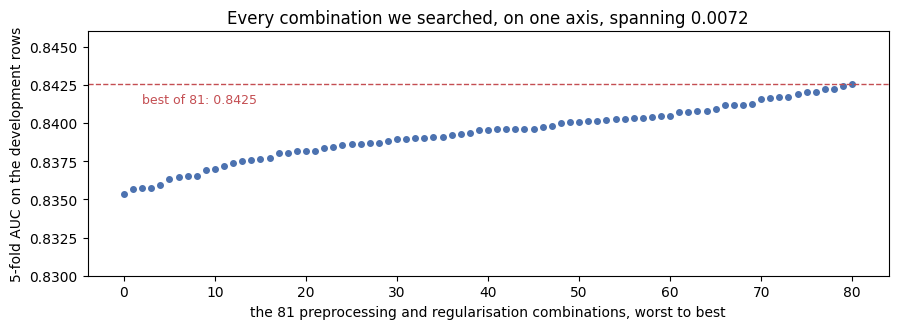

In [20]:
fig, ax = plt.subplots(figsize=(9, 3.4))
ranked = results['mean_test_score'].sort_values().to_numpy()
ax.plot(range(len(ranked)), ranked, 'o', ms=4, color='#4c72b0')
ax.axhline(ranked.max(), color='#c44e52', ls='--', lw=1)
ax.annotate('best of 81: %.4f' % ranked.max(), xy=(2, ranked.max()),
            xytext=(2, ranked.max() - 0.0012), fontsize=9, color='#c44e52')
ax.set_ylim(0.830, 0.846)
ax.set_xlabel('the 81 preprocessing and regularisation combinations, worst to best')
ax.set_ylabel('5-fold AUC on the development rows')
ax.set_title('Every combination we searched, on one axis, spanning %.4f' % np.ptp(ranked))
plt.tight_layout()
plt.show()

Every one of the 81 combinations lands between 0.8354 and 0.8425. The whole search, covering three scalers, three ways of treating a 322-category column, three feature counts and three regularisation strengths, moves the score by **0.0072 end to end**.

The marginal averages say where even that little came from. `C` accounts for most of it, and `C` is a model parameter, not a preprocessing one. Among the genuine preprocessing choices, the scaler is worth 0.0010 from worst to best and the high-cardinality treatment 0.0019.

This is a useful thing to have measured, because the ordering of effort in most projects is exactly backwards. We are conditioned to fuss over preprocessing choices and then reach for a bigger model. On this dataset the preprocessing choices, once the columns are handled sensibly at all, are close to irrelevant. **What mattered was deciding that `Contract` is ordinal and that nine service columns can be counted, and both of those were judgement calls no grid search would have proposed.**

### 7. What you are allowed to claim

We now have a best cross-validated score of 0.8425 and a temptation to write it down as the answer. It is not, and the reason is the one notebook 8 built its final section on: a score you used to choose something is no longer a clean estimate of anything.

There are three different numbers in play and it is worth keeping them apart.

In [21]:
def holdout_auc(fitted, columns=None):
    frame = X_hold if columns is None else X_hold[columns]
    return roc_auc_score(y_hold, fitted.predict_proba(frame)[:, 1])

numeric_pipe = Pipeline([('impute', SimpleImputer(strategy='median')),
                         ('scale', StandardScaler()), ('model', new_lr())])
default_pipe = make_full_pipe()

rows = [
    ('numeric only',
     cross_val_score(numeric_pipe, X_dev[NUMERIC], y_dev, cv=CV, scoring='roc_auc', n_jobs=1).mean(),
     holdout_auc(numeric_pipe.fit(X_dev[NUMERIC], y_dev), NUMERIC)),
    ('full pipeline, nothing tuned',
     cross_val_score(default_pipe, X_dev, y_dev, cv=CV, scoring='roc_auc', n_jobs=1).mean(),
     holdout_auc(default_pipe.fit(X_dev, y_dev))),
    ('full pipeline, best of 81',
     search.best_score_,
     holdout_auc(search)),
]
table = pd.DataFrame(rows, columns=['pipeline', 'development CV', 'held-out'])
table['gap'] = table['development CV'] - table['held-out']
print(table.to_string(index=False, float_format=lambda v: '%.4f' % v))

                    pipeline  development CV  held-out     gap
                numeric only          0.8072    0.8111 -0.0039
full pipeline, nothing tuned          0.8419    0.8360  0.0059
   full pipeline, best of 81          0.8425    0.8365  0.0060


Read the two score columns against each other and the obvious story is that cross-validation was optimistic by about 0.006 and the hold-out corrected it.

That story is wrong, and the giveaway is the middle row. The untuned pipeline shows the same 0.0059 gap, and no hyperparameter of it was ever chosen by looking at that score. A gap that appears whether or not you tuned is not evidence of tuning.

So before drawing any conclusion from it, we should find out how much a single hold-out of 1,407 rows moves on its own.

In [22]:
gaps = []
for seed in range(8):
    Xd, Xh, yd, yh = train_test_split(X, y, test_size=0.2, random_state=seed, stratify=y)
    pipe = make_full_pipe()
    cv_score = cross_val_score(pipe, Xd, yd, cv=CV, scoring='roc_auc', n_jobs=1).mean()
    held = roc_auc_score(yh, pipe.fit(Xd, yd).predict_proba(Xh)[:, 1])
    gaps.append((seed, cv_score, held, cv_score - held))
    print('  split %d   dev CV %.4f   held-out %.4f   gap %+.4f' % gaps[-1])

gap_values = np.array([g[3] for g in gaps])
print()
print('mean gap %+.4f, standard deviation %.4f, from %+.4f to %+.4f'
      % (gap_values.mean(), gap_values.std(), gap_values.min(), gap_values.max()))
print('spread of the 5-fold means:   %.4f' % np.ptp([g[1] for g in gaps]))
print('spread of the single hold-outs: %.4f' % np.ptp([g[2] for g in gaps]))

  split 0   dev CV 0.8403   held-out 0.8471   gap -0.0068


  split 1   dev CV 0.8450   held-out 0.8265   gap +0.0185


  split 2   dev CV 0.8385   held-out 0.8529   gap -0.0144


  split 3   dev CV 0.8434   held-out 0.8301   gap +0.0134


  split 4   dev CV 0.8429   held-out 0.8375   gap +0.0054


  split 5   dev CV 0.8407   held-out 0.8419   gap -0.0012


  split 6   dev CV 0.8414   held-out 0.8403   gap +0.0011


  split 7   dev CV 0.8384   held-out 0.8530   gap -0.0146

mean gap +0.0002, standard deviation 0.0113, from -0.0146 to +0.0185
spread of the 5-fold means:   0.0065
spread of the single hold-outs: 0.0266


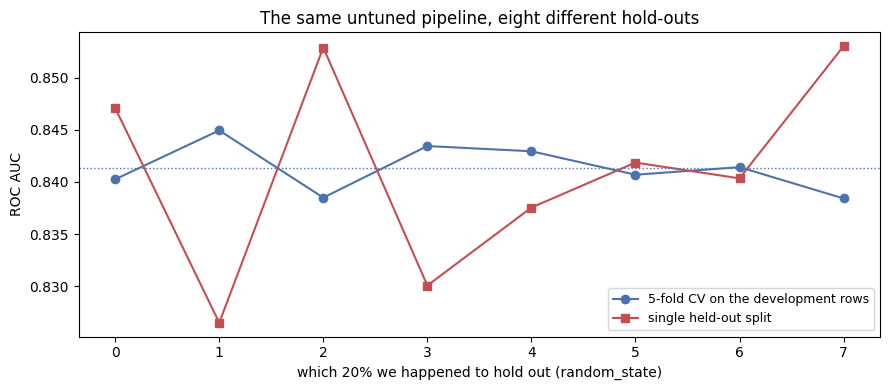

In [23]:
fig, ax = plt.subplots(figsize=(9, 4))
seeds = [g[0] for g in gaps]
ax.plot(seeds, [g[1] for g in gaps], 'o-', label='5-fold CV on the development rows', color='#4c72b0')
ax.plot(seeds, [g[2] for g in gaps], 's-', label='single held-out split', color='#c44e52')
ax.axhline(np.mean([g[1] for g in gaps]), color='#4c72b0', ls=':', lw=1)
ax.set_xlabel('which 20% we happened to hold out (random_state)')
ax.set_ylabel('ROC AUC')
ax.set_title('The same untuned pipeline, eight different hold-outs')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

The gap has a mean of +0.0002 and a standard deviation of 0.0113, and it swings from -0.0146 to +0.0185. It is not a bias, it is noise, and it is noise **larger than every effect the grid search in section 6 measured**.

Two things follow, and both of them are uncomfortable.

The first is that our 0.8360 hold-out figure is not a precise number. Quoting four decimals of a single 1,407-row evaluation implies a precision we have just shown does not exist. The blue line is the steadier of the two by a factor of four, spanning 0.0065 across the eight splits against 0.0266 for the red one, and that is the argument for cross-validating rather than trusting a single split.

The second is that we still have not answered the original question. If the gap is noise, how much did searching 81 combinations actually inflate our best score? For that we need the search to happen inside a fold, which is the same trick as everything else in this notebook applied one level up.

In [24]:
inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
outer = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

nested = cross_val_score(
    GridSearchCV(searchable, grid, cv=inner, scoring='roc_auc', n_jobs=1),
    X, y, cv=outer, scoring='roc_auc', n_jobs=1)

flat = GridSearchCV(searchable, grid, cv=inner, scoring='roc_auc', n_jobs=1).fit(X, y)
untuned = cross_val_score(make_full_pipe(), X, y, cv=outer, scoring='roc_auc', n_jobs=1).mean()

print('nested CV, the search refitted inside every outer fold  %.4f' % nested.mean())
print('  outer folds:', nested.round(4))
print('best-of-81 quoted from the same data it chose on        %.4f' % flat.best_score_)
print('optimism from quoting the winner                        %+.4f' % (flat.best_score_ - nested.mean()))
print()
print('the untuned pipeline, no search at all                  %.4f' % untuned)
print('what the entire search bought                           %+.4f' % (nested.mean() - untuned))

nested CV, the search refitted inside every outer fold  0.8418
  outer folds: [0.8518 0.8439 0.8403 0.8372 0.8358]
best-of-81 quoted from the same data it chose on        0.8419
optimism from quoting the winner                        +0.0001

the untuned pipeline, no search at all                  0.8416
what the entire search bought                           +0.0002


The optimism is **+0.0001**, and the whole search was worth **+0.0002**.

Both of those are more interesting than a big number would have been. Notebook 8's rule explains the first: the inflation from picking a winner scales with how much the candidates disagree. Here all 81 candidates sit inside a 0.0072 band, so there is almost nothing to overfit to, and picking the best of them is nearly free. On notebook 8's noise problem, where the candidates disagreed wildly, the same act of picking a winner was worth 0.27.

**Selection optimism, leak size and candidate instability are three names for one quantity.** That is the single idea this notebook and notebook 8 share, and it applies to choosing features, choosing hyperparameters and choosing between models.

The second number is the one to take to work. Eighty-one fits bought two ten-thousandths of AUC, while deciding what the columns meant, back in notebooks 1, 4 and 7, was worth 0.0329. And even that +0.0002 should not be taken seriously as a gain: the five outer folds above range from 0.8358 to 0.8518, so a difference in the fourth decimal is comfortably inside the noise of the estimate that produced it. The honest summary is that the search bought nothing we can measure, and the column decisions bought three points of AUC.

### 8. Saving the thing, and what breaks

A fitted pipeline is one Python object holding the medians, the means, the category lists, the encodings and the coefficients. `joblib` writes it to a file and reads it back, and that is deployment in two lines.

It is worth being specific about what those two lines do and do not guarantee.

In [25]:
production = make_full_pipe().fit(X_dev, y_dev)
reference = production.predict_proba(X_hold)[:, 1]

path = 'churn_pipeline.joblib'
joblib.dump(production, path)
print('saved %.1f KB' % (os.path.getsize(path) / 1024))

reloaded = joblib.load(path)
print('reloaded predictions bit-for-bit identical:',
      np.array_equal(reference, reloaded.predict_proba(X_hold)[:, 1]))
print('saved from sklearn', sklearn.__version__, '- the file records nothing that enforces this')
os.remove(path)

saved 24.0 KB
reloaded predictions bit-for-bit identical: True
saved from sklearn 1.8.0 - the file records nothing that enforces this


In [26]:
# our service counter uses a named function; the same thing with a lambda cannot be saved
with_lambda = FunctionTransformer(count_services, feature_names_out=lambda t, f: ['num_services'])
try:
    joblib.dump(with_lambda, 'doomed.joblib')
except Exception as err:
    print('%s: %s' % (type(err).__name__, err))
finally:
    # joblib opens the file before it discovers it cannot pickle the lambda
    if os.path.exists('doomed.joblib'):
        os.remove('doomed.joblib')

PicklingError: Can't pickle <function <lambda> at 0x119025760>: it's not found as __main__.<lambda>


This is the failure most likely to catch you, and it catches you at the end of a long training run.

Pickle stores functions and classes **by reference**, not by value. A lambda has no importable name, so it cannot be referenced and cannot be saved. That is why `service_feature_names` in section 3 is a named function rather than the lambda it obviously wants to be.

The same rule applies to `RareCategoryGrouper`. The saved file contains a pointer to the class, not the class itself, so the process that loads it needs the definition importable at the same path. A custom transformer defined in a notebook cell will not load anywhere else. Put them in a module you ship alongside the model.

The version line matters for the same reason. The file has no idea which sklearn wrote it, and loading a pipeline into a different version can range from working perfectly to failing loudly to quietly changing behaviour. Pin your versions next to the model file.

Now the failures that happen while serving, which are the ones a pipeline handles well:

In [27]:
unseen = X_hold.iloc[[0]].copy()
unseen.loc[:, 'PaymentMethod'] = 'Crypto wallet'          # a category invented after training
print('handle_unknown="ignore": %.4f   (unchanged row: %.4f)'
      % (production.predict_proba(unseen)[0, 1], reference[0]))

strict = Pipeline([
    ('prep', ColumnTransformer([('nom', OneHotEncoder(handle_unknown='error'), NOMINAL)],
                               remainder='drop')),
    ('model', new_lr())]).fit(X_dev, y_dev)
try:
    strict.predict_proba(unseen)
except Exception as err:
    print('handle_unknown="error":  %s: %s' % (type(err).__name__, str(err).split(chr(10))[0]))

handle_unknown="ignore": 0.0211   (unchanged row: 0.0154)
handle_unknown="error":  ValueError: Found unknown categories ['Crypto wallet'] in column 5 during transform


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [28]:
new_bundle = X_hold.iloc[[0]].copy()
new_bundle.loc[:, 'bundle'] = 'a combination nobody has bought before'
encoder = production.named_steps['prep'].named_transformers_['hi']
print('TargetEncoder value for an unseen bundle: %.4f' % encoder.transform(new_bundle[['bundle']])[0, 0])
print('training churn rate:                      %.4f' % y_dev.mean())
print('prediction for that row:                  %.4f' % production.predict_proba(new_bundle)[0, 1])

TargetEncoder value for an unseen bundle: 0.2658
training churn rate:                      0.2658
prediction for that row:                  0.0210


In [29]:
missing_value = X_hold.iloc[[0]].copy()
missing_value.loc[:, 'TotalCharges'] = np.nan
print('a NaN at serving time, with the imputer:  %.4f'
      % production.predict_proba(missing_value)[0, 1])

no_imputer = Pipeline([
    ('prep', ColumnTransformer([('num', StandardScaler(), NUMERIC)], remainder='drop')),
    ('model', new_lr())]).fit(X_dev, y_dev)
try:
    no_imputer.predict_proba(missing_value)
except Exception as err:
    print('the same row, without the imputer step: %s: %s' % (type(err).__name__, err))

print()
print('column order shuffled: ',
      'identical' if np.array_equal(reference, production.predict_proba(
          X_hold.sample(frac=1, axis=1, random_state=1))[:, 1]) else 'DIFFERENT')
extra = X_hold.copy(); extra['some_new_column'] = 1
print('an extra column:       ',
      'identical' if np.array_equal(reference, production.predict_proba(extra)[:, 1]) else 'DIFFERENT')
try:
    production.predict_proba(X_hold.drop(columns=['gender']))
except Exception as err:
    print('a missing column:       %s: %s' % (type(err).__name__, err))

a NaN at serving time, with the imputer:  0.0064
the same row, without the imputer step: ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

column order shuffled:  identical
an extra column:        identical
a missing column:       ValueError: columns are missing: {'gender'}


That is the payoff for having been explicit earlier.

- An unseen `PaymentMethod` becomes an all-zero block instead of a crash, because we set `handle_unknown='ignore'`. The prediction moves from 0.0154 to 0.0211, which is the model falling back on everything else it knows about that customer. sklearn warns you it happened, which is the right level of noise: keep the warning, log it, alert if the rate climbs.
- An unseen `bundle` gets the training churn rate, 0.2658, which is the only defensible guess for a category you have never seen.
- A `NaN` in `TotalCharges` is filled with the training median. **The imputer never imputed anything during training**, because we filtered those rows away in the first cell. It is in the pipeline for exactly this moment, and without it the same row raises `Input X contains NaN`.
- Columns can arrive in any order, because `ColumnTransformer` selects by name. An extra column is ignored, because `remainder='drop'`. A missing column fails immediately and says which one.

That last group is a schema check you got for free by listing your columns.

### <font color='green'>Key things to remember from this notebook</font>

A pipeline does not make your model better. Assembling the pipeline made ours better, going from 0.8087 on three numeric columns to 0.8416 with everything handled properly, but every one of those gains was decided in an earlier notebook by thinking about what a column means. The pipeline is what stops you from getting that work subtly wrong.

The leakage rule is worth wildly different amounts depending on what is leaking. Fitting a scaler on all the data cost 0.000001 here and fitting an imputer cost 0.000134, which is nothing in both cases, because both learn aggregate statistics that a fifth of the rows barely move. Target encoding a 322-category column cost 0.020, and selecting 20 features out of 2,000 noise columns cost 0.27. You do not get to know which case you are in ahead of time, and the pipeline covers all of them at no charge.

Not looking at the target is not the same as not looking at the data. Our `RareCategoryGrouper` never touches `y` and still kept 76 categories when fitted on everything against 61 when fitted on the training rows, which changes the width of the feature matrix using rows we were about to score on.

`ColumnTransformer` wants explicit column lists, and `remainder='drop'` should stay the default. That is what kept `customerID` out of the model, and it turns your transformer into a schema that fails loudly when the input changes shape.

Turn on `set_output(transform='pandas')` while you are building. Debugging a nameless numpy array of 18 columns is a waste of an afternoon. Remember that it is incompatible with sparse one-hot output, which is a real constraint on a wide categorical column.

Ask whether a transformer learns anything before writing a class for it. Stateless work like counting services fits in a `FunctionTransformer`. Stateful work needs `fit` to store what it learned, and then it needs to be in the pipeline. Check whether sklearn already has it: our rare-category grouper scored 0.8416 against 0.8415 for `OneHotEncoder(min_frequency=20)`, which is one argument instead of a class to maintain.

A feature is worth whatever it adds to the features already present, not a fixed amount. `bundle` was worth 0.0163 to notebook 4 on a bare numeric baseline and 0.0017 here, once `Contract`, `PaymentMethod`, `InternetService` and `num_services` were in the model. Three different ways of encoding it finished within 0.0001 of each other, and dropping it cost only 0.0017.

Preprocessing settings are hyperparameters once they live in the pipeline, and on this dataset searching them was nearly pointless. All 81 combinations spanned 0.0072, most of that came from `C`, and the whole search improved the honest estimate by 0.0002. Search tunes the last percent. Deciding that `Contract` is ordinal was worth more than the entire grid.

The score you used to choose something is not a score you can quote. Here quoting the best of 81 was inflated by only 0.0001, because the candidates all agreed. Notebook 8 got 0.27 of inflation from the same act, because its candidates did not. Selection optimism, leak size and candidate instability are the same quantity under three names.

Be careful about reading a single hold-out as truth. Across eight random 20% splits of this data the gap between cross-validated and held-out AUC had a mean of +0.0002, a standard deviation of 0.0113, and a range from -0.0146 to +0.0185. The gap we happened to see was noise, not optimism, and it was bigger than every effect the grid search found.

Save with `joblib` and remember that pickle stores code by reference. Lambdas cannot be saved at all, custom classes must be importable at the same path in the serving process, and nothing in the file enforces the sklearn version that wrote it.

<font color='maroon'>The one sentence: a pipeline turns "remember to fit only on training data" from a habit you have to maintain into a property of an object you can hand to someone else.</font>

---

Notebook 10 closes the series by going after the failures that survive all of this. A pipeline makes leakage through preprocessing structurally impossible, and does nothing about a column that should never have been collected, a feature that could not be computed at prediction time in production, or a model that was tuned until the validation set stopped being a validation set.